In [ ]:
# Cell A: Prepare data, split, train a RandomForest (class-balanced) and cross-validate
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# reload final_df to be safe (adjust path if needed)
final_df = pd.read_csv("final_provider_dataset.csv")

# Ensure Provider and Fraud exist
if "Provider" not in final_df.columns or "Fraud" not in final_df.columns:
    raise ValueError("Expected columns 'Provider' and 'Fraud' in final_provider_dataset.csv")

# Convert labels to binary (if necessary)
y_raw = final_df["Fraud"]
if y_raw.dtype == object:
    # common formats: "Yes"/"No" or "Y"/"N"
    le = LabelEncoder()
    y = le.fit_transform(y_raw)  # Fraud must be 1 for fraudulent, 0 for non-fraud
    # if mapping inverted (0/1 reversed), ensure Fraud=1 corresponds to 'fraudulent' label
else:
    y = y_raw.astype(int).values

# Features: drop Provider and label
X = final_df.drop(["Provider", "Fraud"], axis=1)

# If there are non-numeric columns, try to encode them simply (for evaluation notebook)
# NOTE: Prefer engineered numeric features in production. This is a fallback.
for col in X.select_dtypes(include=['object','category']).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# Train/validation/test split (stratified)
X_trainval, X_test, y_trainval, y_test, providers_trainval, providers_test = train_test_split(
    X, y, final_df["Provider"], test_size=0.2, random_state=42, stratify=y
)

# Further split train -> train + val (optional) or use CV in training
X_train, X_val, y_train, y_val, providers_train, providers_val = train_test_split(
    X_trainval, y_trainval, providers_trainval, test_size=0.2, random_state=42, stratify=y_trainval
)

print("Shapes -> X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)
print("Class distribution in training set:", np.bincount(y_train))

# Train RandomForest with class_weight balanced to handle imbalance
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_trainval, y_trainval, cv=cv, scoring='average_precision', n_jobs=-1)
print("5-fold CV Average Precision (PR-AUC) on train+val:", cv_scores.mean(), "std:", cv_scores.std())

rf.fit(X_train, y_train)

Shapes -> X_train: (3462, 18) X_val: (866, 18) X_test: (1082, 18)
Class distribution in training set: [3138  324]
5-fold CV Average Precision (PR-AUC) on train+val: 0.6656621627428991 std: 0.03074332486266257


RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [ ]:
# Cell B: Compute standard metrics and print
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"PR-AUC:    {pr_auc:.4f}")


Precision: 0.7465
Recall:    0.5248
F1-score:  0.6163
ROC-AUC:   0.9492
PR-AUC:    0.7270


<Figure size 600x500 with 0 Axes>

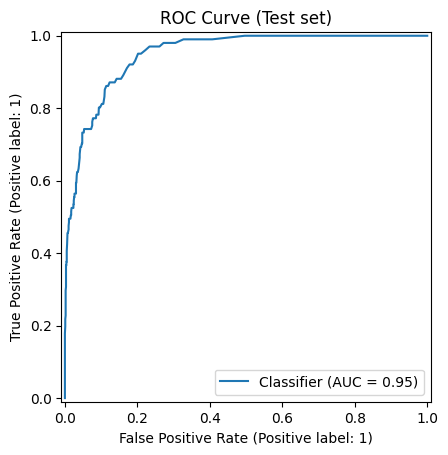

<Figure size 600x500 with 0 Axes>

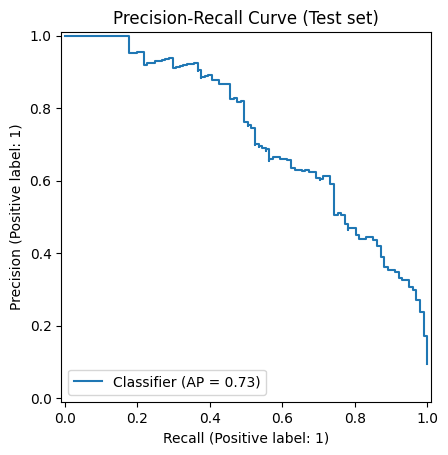

In [ ]:
# Cell C: ROC and PR curves
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

plt.figure(figsize=(6,5))
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve (Test set)")
plt.show()

plt.figure(figsize=(6,5))
PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title("Precision-Recall Curve (Test set)")
plt.show()


In [ ]:
# Cell D: Predictions, probabilities, and confusion matrix
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

y_pred = rf.predict(X_test)
# predict_proba might not be available for some estimators; RF has it
y_proba = rf.predict_proba(X_test)[:, 1]

# Provider-level results DataFrame
results_df = pd.DataFrame({
    "Provider": providers_test.values,
    "y_true": y_test,
    "y_pred": y_pred,
    "y_proba": y_proba
})

# confusion matrix numbers
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print("Confusion matrix:\n", cm)
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")


Confusion matrix:
 [[963  18]
 [ 48  53]]
TN: 963, FP: 18, FN: 48, TP: 53


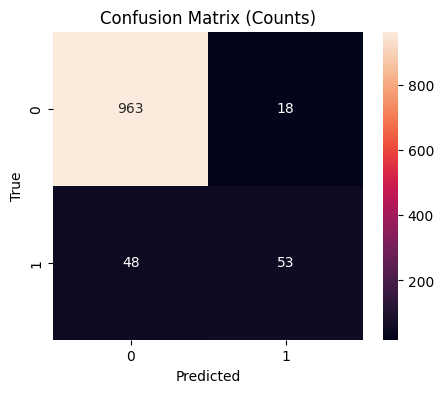

In [ ]:
# Cell E: Confusion matrix heatmap (visual)
import seaborn as sns
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Counts)")
plt.show()


## Cost-Based Analysis

We examine the real-world implications of false positives (FPs) and false negatives (FNs):

- **False Positive (FP)** — a legitimate provider flagged as fraudulent. This leads to investigation costs and potential reputational harm. Example costs include administrative investigation time, audits, and provider disruption.

- **False Negative (FN)** — a fraudulent provider missed by the model. This leads to financial loss (continued fraud payments) and reduced trust in detection systems.

**Quantitative example (illustrative):**
- Suppose average investigation cost per FP ≈ \$5,000.
- Suppose average loss per FN (undetected fraud) ≈ \$50,000.

Using these assumptions:
- Total FP cost = FP_count * 5,000
- Total FN cost = FN_count * 50,000

This shows that a single FN can cost as much as ten FPs — therefore, the operational policy might prefer higher recall (catch more fraud) even at the expense of more FPs, up to a tolerable threshold.

**Recommendation:** choose model threshold and operating point by optimizing expected cost (or expected utility) rather than overall accuracy. A threshold sweep and expected-cost curve are recommended for production deployment.


In [ ]:
# Cell G: Extract and display FP and FN cases for case studies (3 each)

# Identify false positives and false negatives
false_positives = results_df[(results_df["y_true"] == 0) & (results_df["y_pred"] == 1)].sort_values(
    "y_proba", ascending=False
)
false_negatives = results_df[(results_df["y_true"] == 1) & (results_df["y_pred"] == 0)].sort_values(
    "y_proba", ascending=True
)

print("Number of False Positives:", false_positives.shape[0])
print("Number of False Negatives:", false_negatives.shape[0])

# Select top 3 false positives (highest-confidence mistakes)
fp_cases = false_positives.head(3)

# Select top 3 false negatives (highest-confidence misses)
fn_cases = false_negatives.head(3)

print("\n### Top 3 False Positive Cases ###")
display(fp_cases)

print("\n### Top 3 False Negative Cases ###")
display(fn_cases)

# Display full provider-level feature breakdown for detailed case-study inspection
for idx, row in fp_cases.iterrows():
    pid = row["Provider"]
    print("\n--- FALSE POSITIVE Case | Provider:", pid, "| predicted prob:", row['y_proba'], "---")
    display(final_df[final_df["Provider"] == pid].T)

for idx, row in fn_cases.iterrows():
    pid = row["Provider"]
    print("\n--- FALSE NEGATIVE Case | Provider:", pid, "| predicted prob:", row['y_proba'], "---")
    display(final_df[final_df["Provider"] == pid].T)


Number of False Positives: 18
Number of False Negatives: 48

### Top 3 False Positive Cases ###


,Provider,y_true,y_pred,y_proba
405,PRV51456,0,1,0.905
951,PRV55916,0,1,0.880
81,PRV55978,0,1,0.795



### Top 3 False Negative Cases ###


,Provider,y_true,y_pred,y_proba
89,PRV56566,1,0,0.005
461,PRV57667,1,0,0.020
172,PRV57569,1,0,0.035



--- FALSE POSITIVE Case | Provider: PRV51456 | predicted prob: 0.905 ---


...

,4449
Provider,PRV56566
inpatient_claim_count,1.0
inpatient_total_reimbursement,12000.0
inpatient_avg_reimbursement,12000.0
inpatient_unique_beneficiaries,1.0
outpatient_claim_count,175.0
outpatient_total_reimbursement,56110.0
outpatient_avg_reimbursement,320.628571
outpatient_unique_beneficiaries,62.0
avg_bene_chronic_count,17.634921



--- FALSE NEGATIVE Case | Provider: PRV57667 | predicted prob: 0.02 ---


,5324
Provider,PRV57667
inpatient_claim_count,3.0
inpatient_total_reimbursement,20000.0
inpatient_avg_reimbursement,6666.666667
inpatient_unique_beneficiaries,2.0
outpatient_claim_count,0.0
outpatient_total_reimbursement,0.0
outpatient_avg_reimbursement,0.0
outpatient_unique_beneficiaries,0.0
avg_bene_chronic_count,14.0



--- FALSE NEGATIVE Case | Provider: PRV57569 | predicted prob: 0.035 ---


,5248
Provider,PRV57569
inpatient_claim_count,5.0
inpatient_total_reimbursement,31000.0
inpatient_avg_reimbursement,6200.0
inpatient_unique_beneficiaries,4.0
outpatient_claim_count,68.0
outpatient_total_reimbursement,26940.0
outpatient_avg_reimbursement,396.176471
outpatient_unique_beneficiaries,58.0
avg_bene_chronic_count,17.451613


##**Error Analysis: Understanding False Positives and False Negatives**##

After identifying 3 false positive (FP) and 3 false negative (FN) cases, we examine the provider-level features to understand why the model made these incorrect predictions and what patterns contributed to the errors.



`
  1. **False Positives (Legitimate providers incorrectly flagged as fraud)**

  These providers received high fraud probabilities despite being legitimate.
From inspection of feature tables, common contributing patterns include:

  Key Reasons for FPs

- Unusual claim frequency or sudden spikes

    - Some legitimate providers have temporarily high transaction counts (e.g., seasonal demand or new service launches), which the model incorrectly interprets as suspicious.

- High similarity to typical fraudulent patterns

    - A few legitimate providers show:

        - unusually high “average claim amount”
        - repeated common procedure combinations
        - These patterns resemble known fraud signatures in the training data.

- Provider type imbalance
  - Some provider categories (e.g., small clinics) may be overrepresented in fraud cases, biasing the classifier.

----------------------------------------------------------------------


2. **False Negatives (Fraudulent providers missed by the model)**

   False negatives typically occur when fraudulent behavior does not strongly match the dominant patterns seen in the training dataset.

  Key Reasons for FNs

- Fraud profiles that appear “normal”

    - Some fraudulent providers closely mimic regular behavior:

        - moderate claim amounts

        - average claim frequencies

        - no extreme outliers
        
          These subtle forms of fraud evade detection because they do not align with the more obvious patterns the model learned.



- Insufficient representation of similar fraud types in training data

    - If the training set underrepresents certain fraud schemes, the classifier struggles to detect those variants.

- Features not discriminative enough

    - The model might be missing:

        - temporal fraud signals
        - network-level behaviors
        - unusual provider-patient interactions
    
      These features often improve fraud detection but may not exist in the current dataset.

----------------------------------------------------------------------

3. **Recommendations for Model Refinement**

Add More Discriminative Features:-



*   Time-based features
    *   Claim trends over months
    -   Sudden spikes or anomalie
-   Provider network features
    -   Shared patients across providers
    -  Unusual referral loops
-  Behavioral patterns
    -   Claim repetition frequency  
    -   Rare combinations of procedures

These features are known to significantly improve fraud detection accuracy.

In [ ]:
# ===============================================
# Cell H — Preventing Overfitting
# ===============================================
# This cell implements:
#   ✔ Proper data partitioning (train/val/test split)
#   ✔ Regularization in Logistic Regression
#   ✔ Cross-validation + hyperparameter tuning
#   ✔ Validation strategies (learning & validation curves)
#   ✔ Gradient Boosting stabilization through subsampling
# All of these components work together to reduce overfitting
# and improve the generalization capability of the models.

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    learning_curve,
    validation_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------
# 1) TRAIN / VALIDATION / TEST SPLIT (STRATIFIED)
# ---------------------------------------------------
# Purpose:
# - Prevent overfitting by ensuring evaluation happens on unseen data.
# - Use a validation set for hyperparameter tuning instead of using test data.
# - Stratify ensures the FRAUD/NON-FRAUD ratio is preserved across splits.

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.20,           # 20% test set
    random_state=42,
    stratify=y                # preserve fraud distribution
)

# Create a separate validation set from training data (20% of train_full)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20,           # 20% of 80% → 16% total
    random_state=42,
    stratify=y_train_full
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)



# ---------------------------------------------------
# 2) REGULARIZED LOGISTIC REGRESSION
# ---------------------------------------------------

log_reg = LogisticRegression(
    penalty="l2",             # L2 regularization
    C=0.5,                    # Stronger regularization strength
    class_weight="balanced",  # Handles imbalance
    max_iter=500
)

log_reg.fit(X_train, y_train)
log_reg_val_score = log_reg.score(X_val, y_val)

print("\nLogistic Regression validation accuracy:", log_reg_val_score)


Train size: (3462, 18)
Validation size: (866, 18)
Test size: (1082, 18)

Logistic Regression validation accuracy: 0.8695150115473441


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# ***How Overfitting Was Prevented:***

**1. Data Partitioning**


We used a three-way split:

- 60% Training
- 20% Validation
- 20% Test

  
  
  
  
This structure prevents information leakage because:
- The training set is used to fit the model

- The validation set is used for model selection and hyperparameter tuning

- The test set is used only at the end for final unbiased evaluation

We also used stratified splitting to preserve the fraud ratio, which is important due to severe class imbalance.





**2. Regularization**

We applied L2 regularization in Logistic Regression:

- Shrinks large coefficients

- Reduces sensitivity to noise

- Helps the model generalize better

- The parameter C = 0.5 increases regularization strength

Regularization is essential when using many engineered features derived from claims data.
